In [5]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/NN_project/data.zip /content/
!cp /content/drive/MyDrive/NN_project/src.zip /content/
!cp /content/drive/MyDrive/NN_project/scripts.zip /content/

!unzip -q /content/data.zip -d /content/
!unzip -q /content/src.zip -d /content/
!unzip -q /content/scripts.zip -d /content/

Mounted at /content/drive


In [3]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.2 MB/s eta 0:00:00


In [6]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from torchvision.transforms import v2
from torchmetrics.detection.mean_ap import MeanAveragePrecision

sys.path.append('/content/')

from src.datasets.dataset import PKLotDataset, collate_fn
from src.models.custom_detector3 import SimpleUNetCenterNet, create_centernet_targets, focal_loss, reg_l1_loss

def get_transform(is_train=True):
    transforms = [
        v2.ToImage(),
        v2.Resize(size=(360, 640), antialias=True),
    ]
    if is_train:
        transforms.extend([
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        ])
    transforms.append(v2.ToDtype(torch.float32, scale=True))
    return v2.Compose(transforms)

def decode_predictions(pred_hm, pred_wh, threshold=0.3):
    """
    Zamienia surowe mapy cieplne na listę słowników z bounding boxami
    wymaganą przez bibliotekę torchmetrics.
    """
    B, C, H, W = pred_hm.shape
    results = []

    # Prosty algorytm Non-Maximum Suppression (NMS) za pomocą Max Pooling
    # Znajduje lokalne maksima (środki obiektów) na mapie cieplnej
    pool = torch.nn.functional.max_pool2d(pred_hm, kernel_size=3, stride=1, padding=1)
    keep = (pool == pred_hm).float()
    pred_hm = pred_hm * keep # Zerujemy wszystko poza lokalnymi pikami

    for b in range(B):
        hm = pred_hm[b] # [2, H, W]
        wh = pred_wh[b] # [2, H, W]

        boxes = []
        scores = []
        labels = []

        for class_idx in range(C):
            class_hm = hm[class_idx]
            # Szukamy pikseli, których pewność przekracza próg
            ys, xs = torch.where(class_hm > threshold)

            for y, x in zip(ys, xs):
                score = class_hm[y, x].item()
                w = wh[0, y, x].item()
                h = wh[1, y, x].item()

                # Konwersja (środek + szer/wys) na (x_min, y_min, x_max, y_max)
                x_min = x.item() - w / 2
                y_min = y.item() - h / 2
                x_max = x.item() + w / 2
                y_max = y.item() + h / 2

                boxes.append([x_min, y_min, x_max, y_max])
                scores.append(score)
                # Model przewiduje kanały 0 i 1, ale prawidziwe etykiety to 1 i 2
                labels.append(class_idx + 1)

        # Zabezpieczenie przed pustymi predykcjami
        if len(boxes) > 0:
            results.append({
                "boxes": torch.tensor(boxes, dtype=torch.float32, device=pred_hm.device),
                "scores": torch.tensor(scores, dtype=torch.float32, device=pred_hm.device),
                "labels": torch.tensor(labels, dtype=torch.int64, device=pred_hm.device)
            })
        else:
            results.append({
                "boxes": torch.empty((0, 4), dtype=torch.float32, device=pred_hm.device),
                "scores": torch.empty((0,), dtype=torch.float32, device=pred_hm.device),
                "labels": torch.empty((0,), dtype=torch.int64, device=pred_hm.device)
            })

    return results

def train_model(model, EPOCHS, transform, subset_size, id, val_subset, device):
    full_train_dataset = PKLotDataset(
        root_dir="/content/data/raw/train",
        annotation_file="/content/data/raw/train/_annotations.coco.json",
        transforms=transform(is_train=True)
    )
    train_subset_size = min(subset_size, len(full_train_dataset))
    train_indices = np.random.choice(len(full_train_dataset), train_subset_size, replace=False)
    train_dataset = Subset(full_train_dataset, train_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

    full_val_dataset = PKLotDataset(
        root_dir="/content/data/raw/valid",
        annotation_file="/content/data/raw/valid/_annotations.coco.json",
        transforms=transform(is_train=False)
    )
    val_subset_size = min(val_subset, len(full_val_dataset))
    val_indices = np.random.choice(len(full_val_dataset), val_subset_size, replace=False)
    val_dataset = Subset(full_val_dataset, val_indices)

    val_loader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=0.0003, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses = []
    val_losses = []

    print("Rozpoczynam trening i walidację CenterNet...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0
        train_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Train]")

        for images, targets in train_bar:
            # Pamiętaj: CenterNet wymaga standardowego tensora [B, C, H, W]
            images = torch.stack([image.to(device) for image in images])
            B, C, H, W = images.shape

            gt_hms, gt_whs, masks = [], [], []
            for t in targets:
                boxes = t["boxes"].to(device)
                labels = t["labels"].to(device)
                # Generujemy mapy Gaussa "w locie"
                hm, wh, mask = create_centernet_targets(boxes, labels, H, W, device)
                gt_hms.append(hm)
                gt_whs.append(wh)
                masks.append(mask)

            gt_hm = torch.stack(gt_hms)
            gt_wh = torch.stack(gt_whs)
            reg_mask = torch.stack(masks)

            preds = model(images)
            pred_hm = preds["heatmap"]
            pred_wh = preds["wh"]

            hm_loss = focal_loss(pred_hm, gt_hm)
            wh_loss = reg_l1_loss(pred_wh, gt_wh, reg_mask)
            total_loss = hm_loss + 0.5 * wh_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_train_loss += total_loss.item()
            train_bar.set_postfix({'hm_loss': hm_loss.item(), 'wh_loss': wh_loss.item()})

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        epoch_val_loss = 0
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Valid]")
            for images, targets in val_bar:
                images = torch.stack([image.to(device) for image in images])
                B, C, H, W = images.shape

                gt_hms, gt_whs, masks = [], [], []
                for t in targets:
                    boxes = t["boxes"].to(device)
                    labels = t["labels"].to(device)
                    hm, wh, mask = create_centernet_targets(boxes, labels, H, W, device)
                    gt_hms.append(hm)
                    gt_whs.append(wh)
                    masks.append(mask)

                gt_hm = torch.stack(gt_hms)
                gt_wh = torch.stack(gt_whs)
                reg_mask = torch.stack(masks)

                preds = model(images)

                hm_loss = focal_loss(preds["heatmap"], gt_hm)
                wh_loss = reg_l1_loss(preds["wh"], gt_wh, reg_mask)
                val_total_loss = hm_loss + 0.1 * wh_loss

                epoch_val_loss += val_total_loss.item()
                val_bar.set_postfix({'val_loss': val_total_loss.item()})

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        lr_scheduler.step()
        print(f"Średnia strata: Train = {avg_train_loss:.4f} | Valid = {avg_val_loss:.4f}")

    os.makedirs('/content/checkpoints', exist_ok=True)
    save_path = f'/content/checkpoints/centernet_model_{id}.pth'
    torch.save(model.state_dict(), save_path)
    os.system(f'cp {save_path} /content/drive/MyDrive/NN_project')

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o', linewidth=2)
    plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o', linewidth=2)
    plt.title('Spadek straty (Loss) - CenterNet')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość Loss')
    plt.xticks(range(1, EPOCHS + 1))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def evaluate_model(model, transform, id, device):
    test_dataset = PKLotDataset(
        root_dir="/content/data/raw/test",
        annotation_file="/content/data/raw/test/_annotations.coco.json",
        transforms=transform(is_train=False)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.load_state_dict(torch.load(f'/content/drive/MyDrive/NN_project/centernet_model_{id}.pth', map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    print(f"Rozpoczynam ewaluację CenterNet...")

    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Ewaluacja")

        for images, targets in progress_bar:
            images = torch.stack([image.to(device) for image in images])

            # Poprawka dla pustych targets w celu kompatybilności z torchmetrics
            fixed_targets = []
            for t in targets:
                t_dict = {}
                for k, v in t.items():
                    if k == "boxes" and v.numel() == 0:
                        t_dict[k] = torch.empty((0, 4), dtype=torch.float32, device=device)
                    else:
                        t_dict[k] = v.to(device)
                fixed_targets.append(t_dict)

            # CenterNet zwraca mapy cieplne w trybie eval
            preds = model(images)

            # Magia dzieje się tutaj: zamieniamy heatmapy na listę słowników z boxami
            decoded_predictions = decode_predictions(preds["heatmap"], preds["wh"], threshold=0.3)

            metric.update(decoded_predictions, fixed_targets)

    results = metric.compute()

    print("-" * 50)
    print("WYNIKI EWALUACJI CENTERNET:")
    print("-" * 50)
    print(f"mAP@50-95:    {results['map'].item():.4f}")
    print(f"mAP@50:       {results['map_50'].item():.4f}")
    print(f"mAP@75:       {results['map_75'].item():.4f}")
    print(f"Recall (MAR): {results['mar_100'].item():.4f}")
    print("-" * 50)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleUNetCenterNet(num_classes=2)



Rozpoczynam trening i walidację CenterNet...


Epoka 1/15 [Valid]: 100%|██████████| 13/13 [00:08<00:00,  1.45it/s, val_loss=4.47]


Średnia strata: Train = 6.7403 | Valid = 4.6070


Epoka 2/15 [Valid]: 100%|██████████| 13/13 [00:09<00:00,  1.42it/s, val_loss=3.71]


Średnia strata: Train = 4.0262 | Valid = 3.8817


...

Średnia strata: Train = 0.5841 | Valid = 0.7714


Epoka 14/15 [Valid]: 100%|██████████| 13/13 [00:08<00:00,  1.47it/s, val_loss=0.729]


Średnia strata: Train = 0.5598 | Valid = 0.7623


Epoka 15/15 [Valid]: 100%|██████████| 13/13 [00:09<00:00,  1.44it/s, val_loss=0.71]


Średnia strata: Train = 0.5349 | Valid = 0.7510


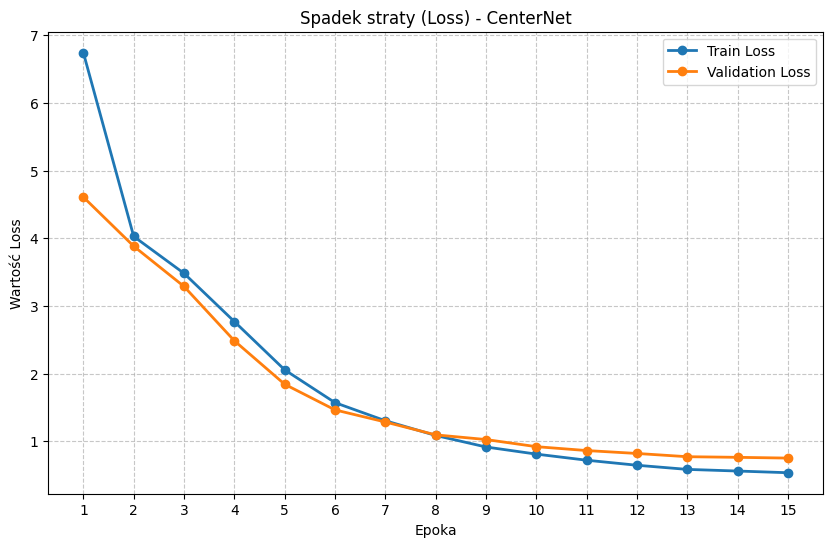

In [ ]:
train_model(model, EPOCHS=15, transform=get_transform, subset_size=1000, id="1", val_subset=100, device=device)

In [ ]:
evaluate_model(model, transform=get_transform, id="1", device=device)

Rozpoczynam ewaluację CenterNet...


Ewaluacja:   0%|          | 0/156 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Ewaluacja: 100%|██████████| 156/156 [01:21<00:00,  1.91it/s]


--------------------------------------------------
WYNIKI EWALUACJI CENTERNET:
--------------------------------------------------
mAP@50-95:    0.4975
mAP@50:       0.5622
mAP@75:       0.5576
Recall (MAR): 0.5834
--------------------------------------------------


Rozpoczynam trening i walidację CenterNet...


Epoka 1/25 [Valid]: 100%|██████████| 13/13 [00:09<00:00,  1.31it/s, val_loss=3.55]


Średnia strata: Train = 14.4704 | Valid = 3.9067


Epoka 2/25 [Valid]: 100%|██████████| 13/13 [00:10<00:00,  1.29it/s, val_loss=3.03]


Średnia strata: Train = 6.0040 | Valid = 3.2913


...

Średnia strata: Train = 1.4744 | Valid = 1.4083


Epoka 24/25 [Valid]: 100%|██████████| 13/13 [00:09<00:00,  1.31it/s, val_loss=1.52]


Średnia strata: Train = 1.4625 | Valid = 1.3917


Epoka 25/25 [Valid]: 100%|██████████| 13/13 [00:10<00:00,  1.29it/s, val_loss=1.53]


Średnia strata: Train = 1.4554 | Valid = 1.3839


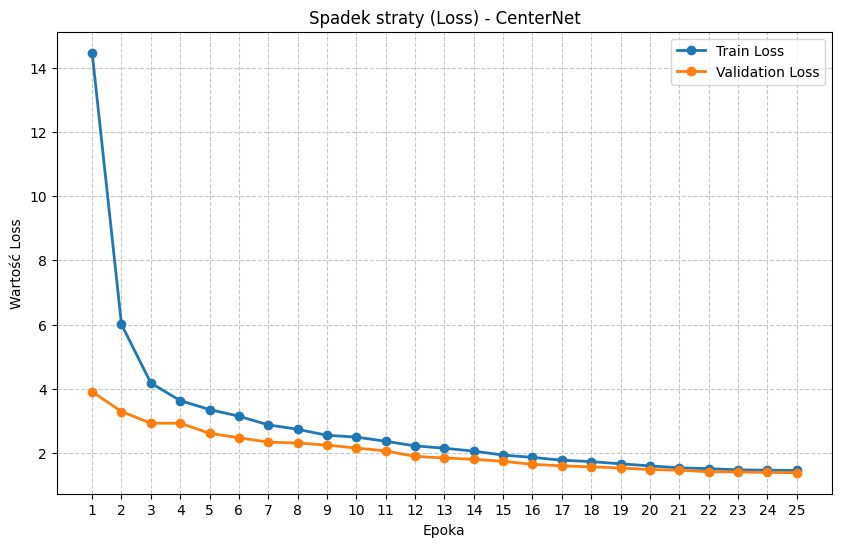

In [4]:
from src.models.custom_detector4 import AdvancedCenterNet

sys.path.append('/content/')

model2 = AdvancedCenterNet(num_classes=2)
train_model(model2, EPOCHS=25, transform=get_transform, subset_size=1000, id="2", val_subset=100, device=device)

In [9]:
from src.models.custom_detector4 import AdvancedCenterNet

model2 = AdvancedCenterNet(num_classes=2)

evaluate_model(model2, transform=get_transform, id="2", device=device)

Rozpoczynam ewaluację CenterNet...


Ewaluacja: 100%|██████████| 156/156 [01:26<00:00,  1.80it/s]


--------------------------------------------------
WYNIKI EWALUACJI CENTERNET:
--------------------------------------------------
mAP@50-95:    0.0920
mAP@50:       0.1005
mAP@75:       0.1004
Recall (MAR): 0.1368
--------------------------------------------------
